# Week 3 Notebook 1: Choosing the right plot

**CSC: Data Analytics, Data Mining and Machine Learning**

Every plot in this notebook answers a **question**. Pick the plot by the question, not by what looks impressive.

### Today’s goal
By the end, you should be able to look at a research question and decide which kind of plot will help answer it. You do **not** need to memorise plotting functions yet.

You will practise five common plot families:

| Question | Plot family |
|---|---|
| What does one variable look like? | **Distribution** |
| How do groups compare? | **Comparison** |
| Do two variables move together? | **Relationship** |
| How does something change over time? | **Time** |
| What are the shares of a whole? | **Part-to-whole** |

**A useful habit:** say the question out loud before you write plotting code.

In [5]:
# Import libraries and give them short, conventional aliases.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use a consistent style for all charts in this notebook.
sns.set_theme(style="whitegrid")

## Meet the Palmer Penguins

Before we start making plots, we will look at a small dataset about penguins measured at Palmer Station in Antarctica. The artwork below shows three penguin species represented in the dataset.

![Palmer Penguins artwork](../assets/penguins.png)

*Artwork by @allison_horst*

In [6]:
df = pd.read_csv("../data/penguins.csv")
df.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


### What this setup does

- `pandas` works with table-shaped data such as CSV files.
- `numpy` provides useful numerical tools and arrays.
- `matplotlib.pyplot` creates charts and controls their appearance.
- `seaborn` provides easier-to-read statistical charts built on matplotlib.

The short names `pd`, `np`, `plt`, and `sns` are aliases. They save typing, but they still refer to the imported libraries.

The last two lines set a consistent chart style and load the penguins data into a variable called `df`. The name `df` is short for **DataFrame**, pandas' name for a table. The final line displays the first three rows so you can check what the data looks like before plotting it.

---
## 0. Why plot before you calculate?

Four datasets can have almost exactly the same summary statistics and still look completely different. This is **Anscombe’s quartet**.

**Before looking at the plots:** What do you expect the four datasets to look like?

,x_mean,y_mean,x_var,y_var,r
dataset,,,,,
I,9.0,7.5,11.0,4.13,0.82
II,9.0,7.5,11.0,4.13,0.82
III,9.0,7.5,11.0,4.12,0.82
IV,9.0,7.5,11.0,4.12,0.82


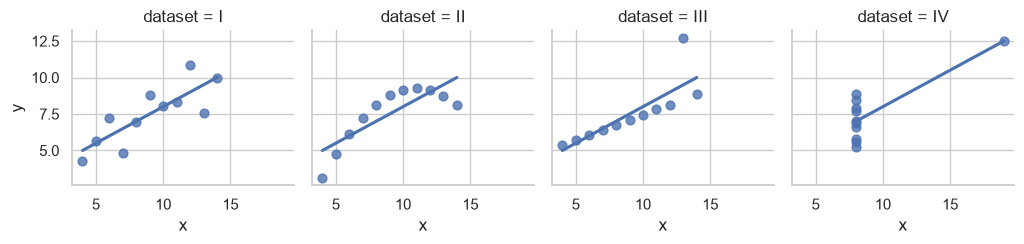

In [7]:
# Build Anscombe's quartet as one table.
x = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
ys = {
    "I":   (x, [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]),
    "II":  (x, [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]),
    "III": (x, [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
    "IV":  ([8] * 7 + [19] + [8] * 3,
            [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]),
}
anscombe = pd.DataFrame(
    [(name, xi, yi) for name, (xs, yv) in ys.items() for xi, yi in zip(xs, yv)],
    columns=["dataset", "x", "y"],
)

# Calculate the same summaries that make the four datasets look similar.
summary = anscombe.groupby("dataset").agg(
    x_mean=("x", "mean"), y_mean=("y", "mean"),
    x_var=("x", "var"), y_var=("y", "var"),
)
summary["r"] = anscombe.groupby("dataset")[["x", "y"]].corr().xs("x", level=1)["y"]
display(summary.round(2))

# Plot the observations to reveal how different the datasets really are.
sns.lmplot(data=anscombe, x="x", y="y", col="dataset", col_wrap=4,
           ci=None, height=2.6, scatter_kws={"s": 40})
plt.show()

---
## 1. Distribution: what does one variable look like?

Use a distribution plot when your question is about the **shape or spread of one numeric variable**.

You will use a histogram and a box plot.

Look for: typical values, spread, skew, gaps, and possible unusual values.

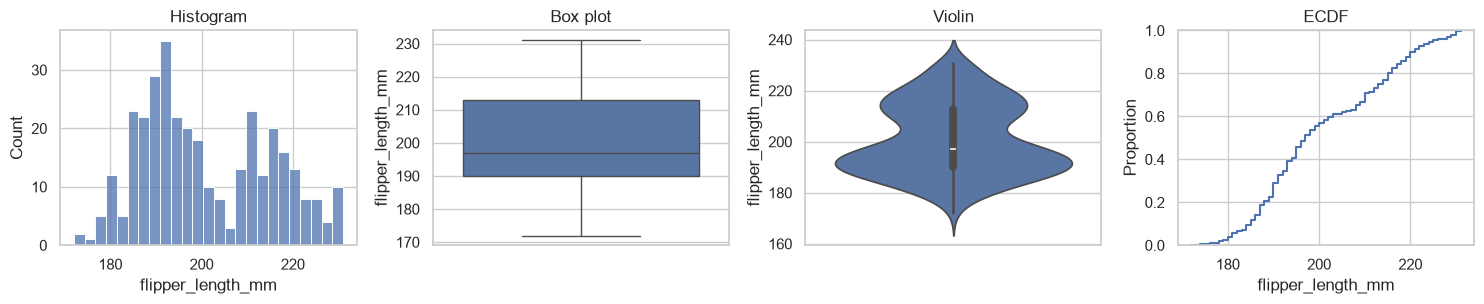

In [8]:
# Compare four ways to show the distribution of one numeric column.
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))

sns.histplot(data=df, x="flipper_length_mm", bins=25, ax=axes[0])
axes[0].set_title("Histogram")

sns.boxplot(data=df, y="flipper_length_mm", ax=axes[1])
axes[1].set_title("Box plot")

sns.violinplot(data=df, y="flipper_length_mm", ax=axes[2])
axes[2].set_title("Violin")

sns.ecdfplot(data=df, x="flipper_length_mm", ax=axes[3])
axes[3].set_title("ECDF")

plt.tight_layout()
plt.show()

### Quick check

- A **histogram** shows the shape of the distribution.
- A **box plot** gives a compact summary of centre, spread and possible outliers.

There is no single perfect plot. The right choice depends on what you need the reader to see.

---
## 2. Comparison: how do groups compare?

If your question is **“Do groups differ?”**, comparison plots are useful.

A bar chart of means gives only one number per group. When the individual observations matter, show them too.

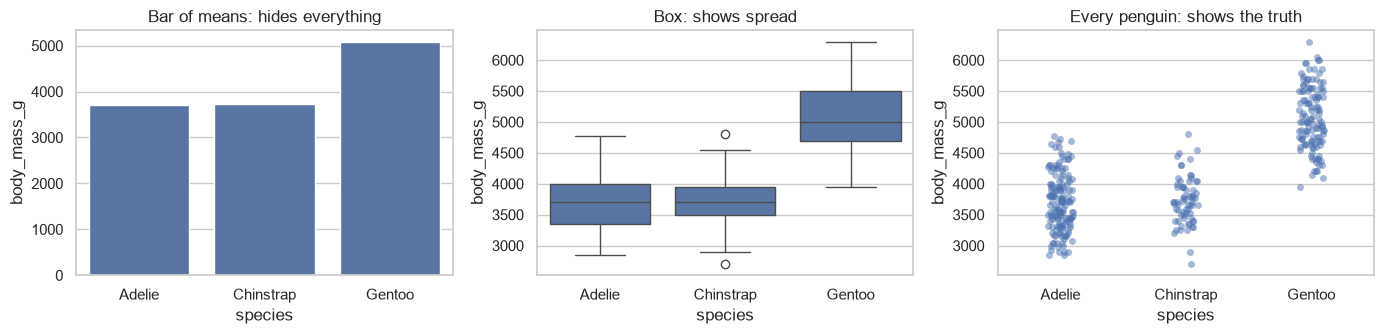

In [9]:
# Compare a summary plot, a spread plot, and the individual observations.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

sns.barplot(data=df, x="species", y="body_mass_g", errorbar=None, ax=axes[0])
axes[0].set_title("Bar of means: hides everything")

sns.boxplot(data=df, x="species", y="body_mass_g", ax=axes[1])
axes[1].set_title("Box: shows spread")

sns.stripplot(data=df, x="species", y="body_mass_g", alpha=0.5, ax=axes[2])
axes[2].set_title("Every penguin: shows the truth")

plt.tight_layout()
plt.show()

### What should you notice?

The mean can hide the distribution of the observations. For small or moderate datasets, showing the individual points can make the comparison much more informative.

---
## 3. Relationship: do two variables move together?

When your question is **“Is X associated with Y?”**, start with a scatter plot.

Here we compare bill length and bill depth. The displayed `r` value is **Pearson correlation**, the default method used by pandas. It measures a straight-line relationship, not every possible kind of association. First look at the overall pattern; then split by species.

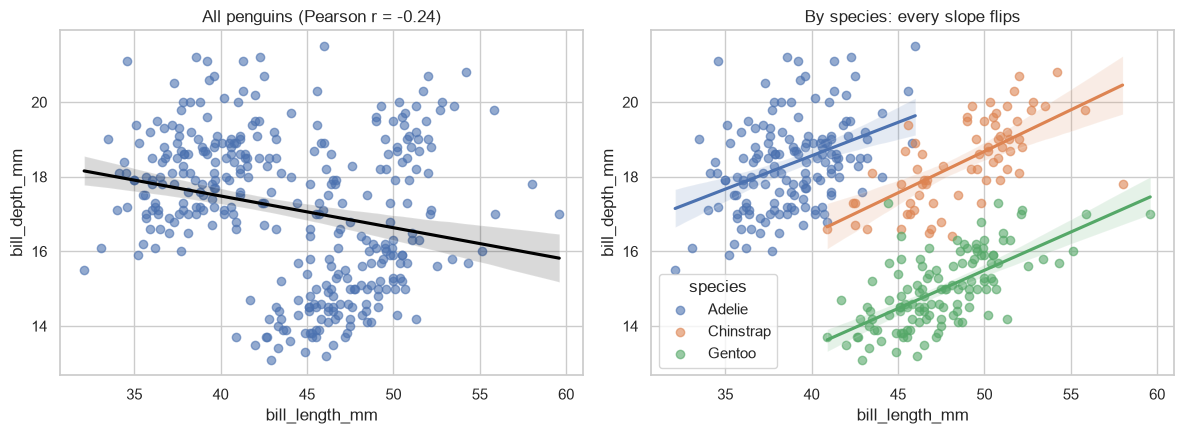

overall:  -0.235
Adelie       0.391
Chinstrap    0.654
Gentoo       0.643


In [10]:
# Remove rows missing either variable before calculating correlations.
sub = df.dropna(subset=["bill_length_mm", "bill_depth_mm"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: the overall relationship across all penguins.
# corr() uses Pearson correlation by default, so the line measures linear association.
sns.regplot(data=sub, x="bill_length_mm", y="bill_depth_mm",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "black"}, ax=axes[0])
axes[0].set_title(f"All penguins (Pearson r = {sub['bill_length_mm'].corr(method='pearson', other=sub['bill_depth_mm']):.2f})")

# Right: draw one fitted line for each species.
for sp, g in sub.groupby("species"):
    sns.regplot(data=g, x="bill_length_mm", y="bill_depth_mm",
                scatter_kws={"alpha": 0.6}, label=sp, ax=axes[1])
axes[1].legend(title="species")
axes[1].set_title("By species: every slope flips")

plt.tight_layout()
plt.show()

print("overall: ", round(sub["bill_length_mm"].corr(method="pearson", other=sub["bill_depth_mm"]), 3))
for sp, g in sub.groupby("species"):
    print(f"{sp:12s}", round(g["bill_length_mm"].corr(method="pearson", other=g["bill_depth_mm"]), 3))

### A warning about grouping: Simpson’s paradox

The overall trend can differ from the trend inside each group. The aggregate is not necessarily “wrong”, it may be answering a different question.

**Lesson:** when groups are substantively important, check whether the relationship changes when you split the data by group.

---
## 4. Time: how does it change?

When observations have a meaningful time order, use a **line plot**. Time normally goes on the x-axis from left to right.

The penguins dataset has no time variable, so we use a small simulated example. The thin lines show daily measurements. The thicker black line shows a **rolling mean**, which helps reveal the overall trend.

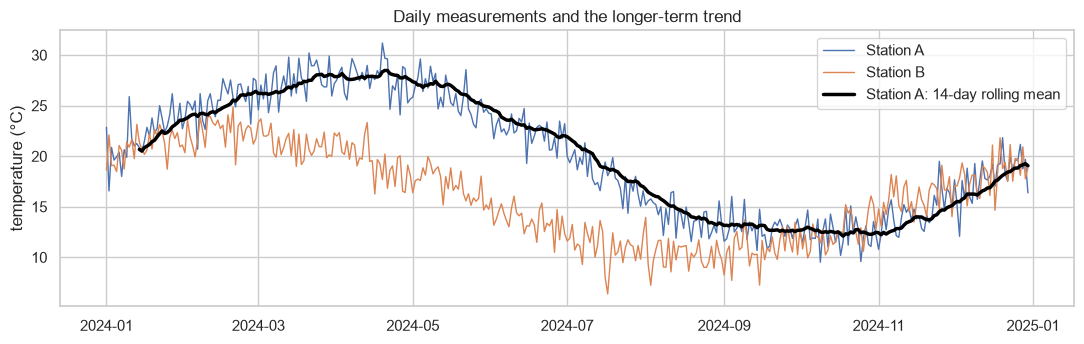

In [11]:
# Create one year of reproducible example data.
rng = np.random.default_rng(3)
dates = pd.date_range("2024-01-01", periods=365)
ts = pd.DataFrame({
    "date": dates,
    "station_a": 20 + 8 * np.sin(np.arange(365) / 58) + rng.normal(0, 1.4, 365),
    "station_b": 16 + 6 * np.sin(np.arange(365) / 58 + 0.7) + rng.normal(0, 1.4, 365),
})

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(ts["date"], ts["station_a"], label="Station A", lw=1)
ax.plot(ts["date"], ts["station_b"], label="Station B", lw=1)

# For each day, average Station A's value over a 14-day window.
# This uses the current day and the previous 13 days, reducing daily noise.
station_a_rolling_mean = ts["station_a"].rolling(14).mean()
ax.plot(
    ts["date"],
    station_a_rolling_mean,
    lw=2.5,
    color="black",
    label="Station A: 14-day rolling mean",
)

ax.set_ylabel("temperature (°C)")
ax.legend()
ax.set_title("Daily measurements and the longer-term trend")
plt.tight_layout()
plt.show()

---
## 5. Part-to-whole: how much of the whole is each category?

A pie chart can show shares of a whole, but comparing **lengths or positions** is usually easier than comparing angles.

For that reason, a bar chart is often easier to read.

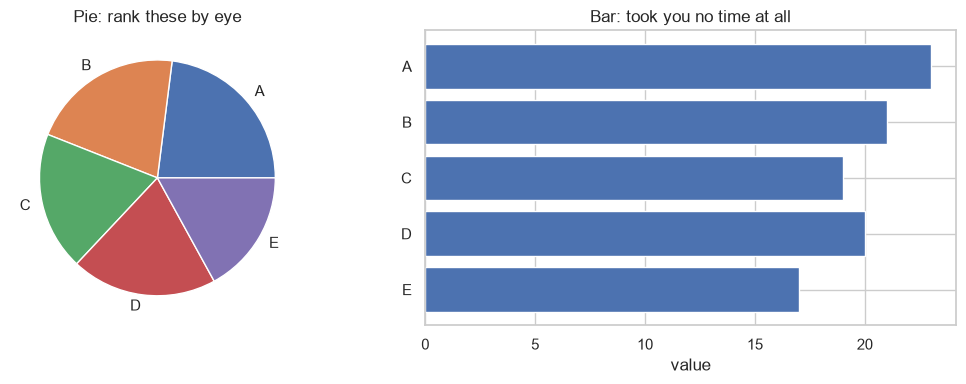

In [12]:
labels = ["A", "B", "C", "D", "E"]
values = [23, 21, 19, 20, 17]

# Compare the same values as angles and as bar lengths.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(values, labels=labels, autopct=None)
axes[0].set_title("Pie: rank these by eye")

axes[1].barh(labels[::-1], values[::-1])
axes[1].set_xlabel("value")
axes[1].set_title("Bar: took you no time at all")

plt.tight_layout()
plt.show()

---
## Good practice: seven lines

1. Answer **one question per plot**. Say the question out loud first.
2. Plot the **raw data** before you plot a summary of it.
3. Split by relevant groups when a group variable could change the story.
4. Label axes clearly and include units.
5. Use colour to communicate information, not just decoration.
6. Avoid unnecessary 3D effects, dual axes, and other visual tricks that make comparison harder.
7. Make the important pattern easy to see; do not make the reader hunt for it.

---
## Practice: Choose a Plot Before You Code

An example question is:

> **Do penguin species differ in body mass, and how much do individual penguins vary within each species?**

Choose one option for each question:

| Question | Options |
|---|---|
| Plot family | `distribution`, `comparison`, `relationship`, `time`, `part-to-whole` |
| x-axis variable | `species`, `island`, `bill_length_mm`, `bill_depth_mm` |
| y-axis variable | `body_mass_g`, `flipper_length_mm`, `bill_length_mm`, `bill_depth_mm` |
| Show individual observations? | `True` or `False` |
| Start a bar-chart y-axis at zero? | `True` or `False` |

The question asks about differences between species, so choose the comparison family. The chart should use `species` on the x-axis and `body_mass_g` on the y-axis. Showing the individual penguins helps you see how much they vary within each species. If a bar chart is used, its y-axis should start at zero because bar length represents the values.

Fill in the choices below. The checking cell tests the design, not one particular plotting function.

In [1]:
# Choose one option from the list in the instructions for each variable.
# Example: plot_family = "comparison"
plot_family = None
x_variable = None
y_variable = None
show_individuals = None
bar_axis_starts_at_zero = None

Run the next cell after filling in your answers. The checker is stored in the project `tests/` folder.

In [2]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd()
if not (project_root / "tests").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import tests.test_plot_families as plot_tests
importlib.reload(plot_tests)

plot_tests.check_plot_design(globals())

Some answers are missing or need another look. Review the question and try again.


False